In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML -> Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
'''
Gender
-----------
1 -> Female
2 -> Male

Cholestrol
----------------
1 -> Good
2 -> Average
3 -> High

Glucose
----------------
1 -> Good
2 -> Average
3 -> High

Smoke, Alcohol, Active
------------------------
0 -> No
1 -> Yes
'''

'\nGender\n-----------\n1 -> Female\n2 -> Male\n\nCholestrol\n----------------\n1 -> Good\n2 -> Average\n3 -> High\n\nGlucose\n----------------\n1 -> Good\n2 -> Average\n3 -> High\n\nSmoke, Alcohol, Active\n------------------------\n0 -> No\n1 -> Yes\n'

In [3]:
df = pd.read_csv('Dataset/Cardiovascular_Disease.csv')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN


### Data cleaning

In [4]:
df['age'] = round(df['age']/365, 2)

In [5]:
df['ap_lo'].max()

11000

#### cleaning pressure data

In [6]:
pressure = (df['ap_hi'].between(100, 200)) & (df['ap_lo'].between(50, 90))

In [7]:
df = df[pressure]

In [8]:
df['height'].min()

55

In [9]:
weight_data = (df['weight'] >= 40) & (df['weight'] <= 140)
df = df[weight_data]

In [10]:
height = (df['height']>=120)
df = df[height]

## Feature and Target Selection

In [11]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')

In [12]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 
            'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [13]:
X = df[features]
Y = df[target]

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [15]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [16]:
model = LogisticRegression(
    solver = 'lbfgs',
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scale, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
Y_pred = model.predict(X_test_scale)

### Metrics

In [18]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [19]:
print(cr)

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6576
           1       0.72      0.66      0.69      5903

    accuracy                           0.72     12479
   macro avg       0.72      0.71      0.71     12479
weighted avg       0.72      0.72      0.72     12479



In [20]:
print(cm)

[[5036 1540]
 [1998 3905]]


<Axes: >

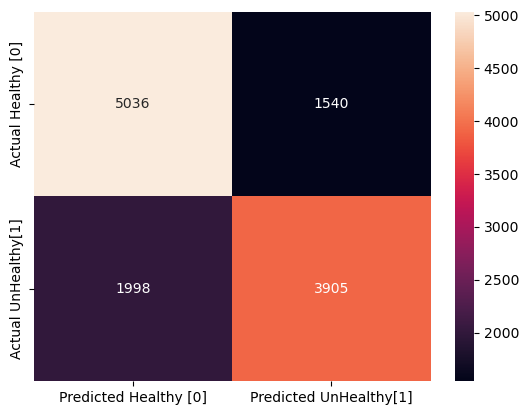

In [32]:
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=['Predicted Healthy [0]', 'Predicted UnHealthy[1]'],
           yticklabels=['Actual Healthy [0]', 'Actual UnHealthy[1]'])

### new data prediction

In [33]:
input_data = {
    'age': [40, 30, 25, 50], 
    'gender': [1, 2, 2, 1], 
    'height': [150, 135, 168, 155], 
    'weight': [60, 50, 80, 55], 
    'ap_hi': [150, 130, 120, 140], 
    'ap_lo': [80, 80, 80, 80], 
    'cholesterol': [3, 2, 2, 1], 
    'gluc': [3, 2, 2, 1], 
    'smoke': [1, 1, 0, 0], 
    'alco': [0, 1, 0, 1], 
    'active': [0, 1, 1, 0]
}
X_new = pd.DataFrame(input_data)

In [34]:
X_new_scale = scaler.transform(X_new)

In [35]:
Y_new_pred = model.predict(X_new_scale)

In [36]:
X_new['Predicted Cardio'] = Y_new_pred

In [38]:
pc = {
    0: 'Likely to be Healthy.',
    1: 'Likely to be UnHealthy.'
}
X_new['Predicted Cardio'] = X_new['Predicted Cardio'].map(pc)

In [39]:
X_new

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Predicted Cardio
0,40,1,150,60,150,80,3,3,1,0,0,Likely to be UnHealthy.
1,30,2,135,50,130,80,2,2,1,1,1,Likely to be Healthy.
2,25,2,168,80,120,80,2,2,0,0,1,Likely to be Healthy.
3,50,1,155,55,140,80,1,1,0,1,0,Likely to be UnHealthy.
